We’ll test one HSI strategy through multiple lenses:

If 50-day moving average > 200-day moving average:
    be invested in HSI

If 50-day moving average < 200-day moving average:
    stay in cash

[*********************100%***********************]  1 of 1 completed


DATASET BUILT
----------------------------------------
Rows: 3867
Start date: 2010-10-22 00:00:00
End date: 2026-07-15 00:00:00

Columns:
['price', 'daily_return', 'ma_50', 'ma_200', 'rolling_vol_60', 'vol_regime']

Latest row:
                   price  daily_return         ma_50        ma_200  \
Date                                                                 
2026-07-15  24667.080078      0.018723  24843.338281  25827.460801   

            rolling_vol_60 vol_regime  
Date                                   
2026-07-15        0.187025   High Vol  

Volatility regime counts:
vol_regime
Low Vol     1950
High Vol    1917
Name: count, dtype: int64


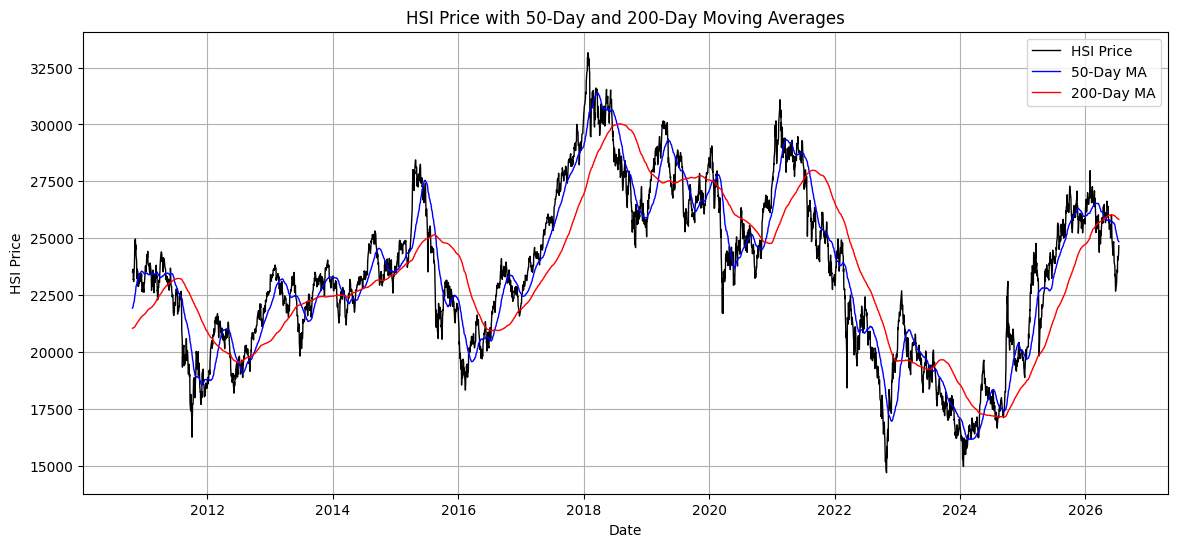


ADF Test: HSI Price
ADF statistic: -2.7043
P-value: 0.0733
Used lags: 0
Observations: 4065
Critical values:
  1%: -3.4320
  5%: -2.8623
  10%: -2.5671
Conclusion: Cannot reject non-stationarity. Series may be non-stationary.

ADF Test: HSI Simple Returns
ADF statistic: -63.2597
P-value: 0.0000
Used lags: 0
Observations: 4064
Critical values:
  1%: -3.4320
  5%: -2.8623
  10%: -2.5671
Conclusion: Reject non-stationarity. Series is likely stationary.

ADF Test: HSI Log Returns
ADF statistic: -63.2740
P-value: 0.0000
Used lags: 0
Observations: 4064
Critical values:
  1%: -3.4320
  5%: -2.8623
  10%: -2.5671
Conclusion: Reject non-stationarity. Series is likely stationary.


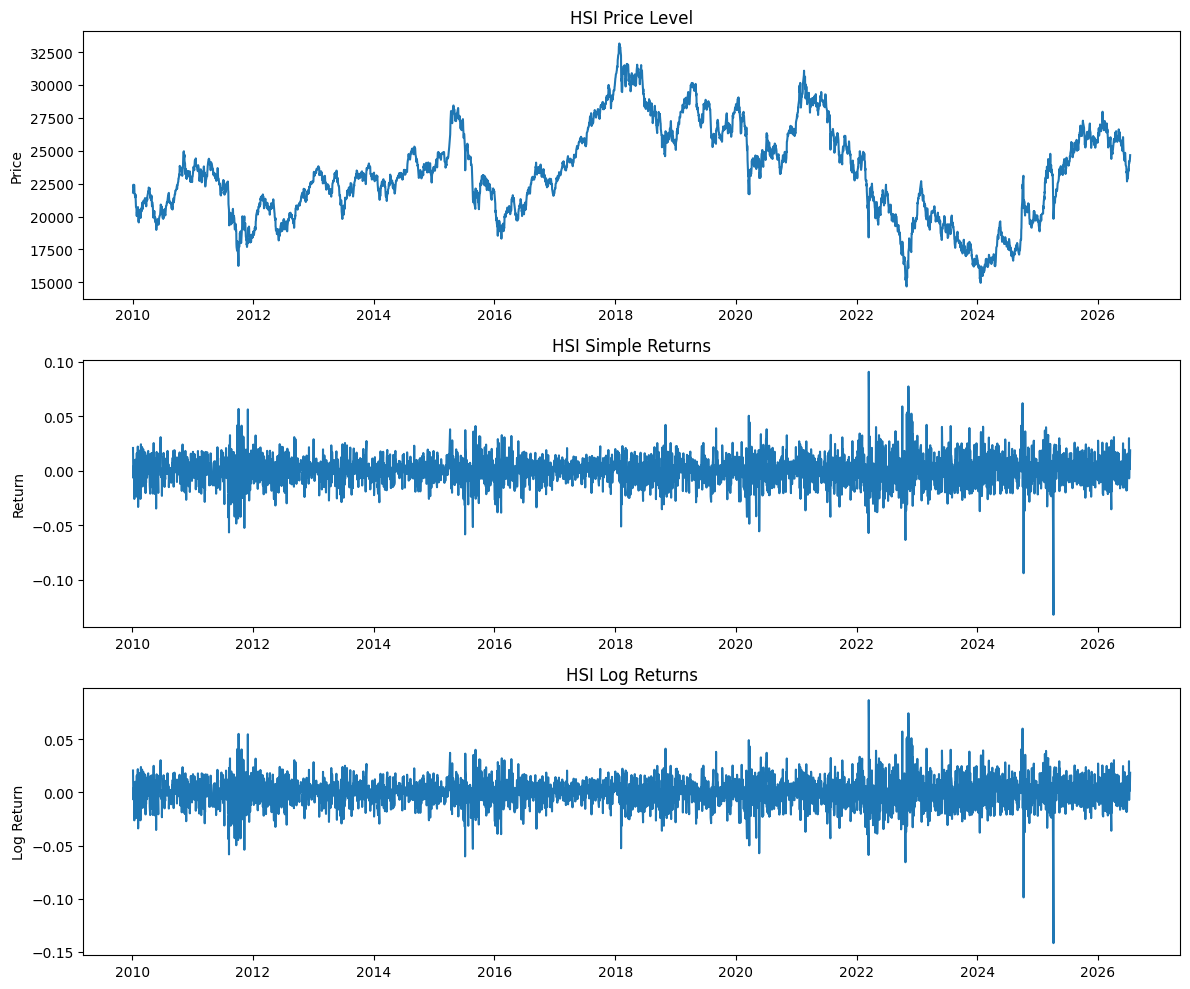

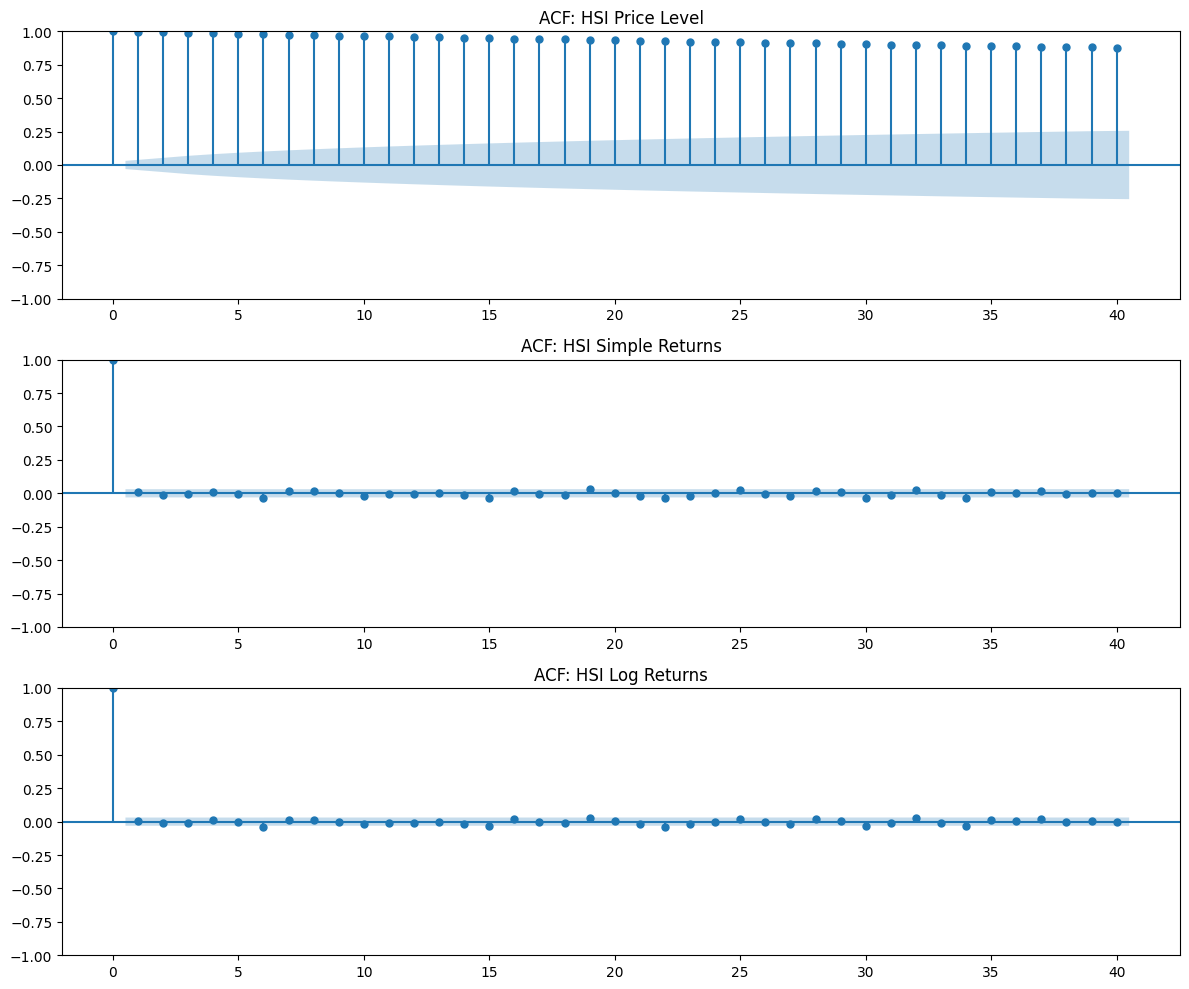


Spurious Regression Demonstration
R-squared: 0.92%
P-value for fake price coefficient: 0.0000
Interpretation: A high R² or low p-value here would be misleading because the fake price was built from shuffled returns and has no real time relationship to HSI.


In [ ]:
#Q1: Is the price series stationary? (We check stationarity to avoid building a “statistical” strategy on something that behaves like a drifting time series.
#It’s basically a sanity check before doing serious analysis.)

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# -----------------------------
# 1. Download HSI price data
# -----------------------------

ticker = "^HSI"

prices = yf.download(
    ticker,
    start="2010-01-01",
    auto_adjust=True
)["Close"]

# Sometimes yfinance returns a DataFrame instead of a Series.
# This makes sure we have one clean price series.
if isinstance(prices, pd.DataFrame):
    prices = prices.iloc[:, 0]

prices = prices.dropna()

# -----------------------------
# 2. Create dataset
# -----------------------------

df = pd.DataFrame()

# Price = closing level of the Hang Seng Index.
df["price"] = prices

# Daily return = percentage change from yesterday's price to today's price.
# Example:
# If price goes from 20000 to 20200, return = 1%.
df["daily_return"] = df["price"].pct_change()

# -----------------------------
# 3. Moving averages
# -----------------------------

# 50-day moving average:
# Average price over the last 50 trading days.
# This represents the medium-term trend.
df["ma_50"] = df["price"].rolling(50).mean()

# 200-day moving average:
# Average price over the last 200 trading days.
# This represents the long-term trend.
df["ma_200"] = df["price"].rolling(200).mean()

# -----------------------------
# 4. Rolling volatility
# -----------------------------

# 60-day rolling volatility:
# Standard deviation of daily returns over the last 60 trading days.
# Then we annualize it by multiplying by sqrt(252).
#
# 252 is used because there are about 252 trading days in one year.
df["rolling_vol_60"] = df["daily_return"].rolling(60).std() * np.sqrt(252)

# -----------------------------
# 5. Volatility regime
# -----------------------------

# Volatility threshold:
# We use the median rolling volatility as the cutoff.
# If rolling volatility is above this level, we call it High Vol.
# If rolling volatility is below this level, we call it Low Vol.
vol_threshold = df["rolling_vol_60"].median()

df["vol_regime"] = np.where(
    df["rolling_vol_60"] > vol_threshold,
    "High Vol",
    "Low Vol"
)

# -----------------------------
# 6. Clean dataset
# -----------------------------

# Drop missing rows.
# Missing rows happen because moving averages and rolling volatility
# need enough past data before they can be calculated.
df = df.dropna()

# -----------------------------
# 7. Basic checks
# -----------------------------

print("DATASET BUILT")
print("-" * 40)

print("Rows:", len(df))
print("Start date:", df.index.min())
print("End date:", df.index.max())

print("\nColumns:")
print(df.columns.tolist())

print("\nLatest row:")
print(df.tail(1))

print("\nVolatility regime counts:")
print(df["vol_regime"].value_counts())

# -----------------------------
# 8. Quick plot
# -----------------------------

plt.figure(figsize=(14, 6))

plt.plot(df.index, df["price"], label="HSI Price", color="black", linewidth=1)
plt.plot(df.index, df["ma_50"], label="50-Day MA", color="blue", linewidth=1)
plt.plot(df.index, df["ma_200"], label="200-Day MA", color="red", linewidth=1)

plt.title("HSI Price with 50-Day and 200-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("HSI Price")
plt.legend()
plt.grid(True)
plt.show()


simple_returns = prices.pct_change(fill_method=None).dropna()
log_prices = np.log(prices)
log_returns = log_prices.diff().dropna()

series_dict = {
    "HSI Price": prices,
    "HSI Simple Returns": simple_returns,
    "HSI Log Returns": log_returns,
}

# ------------------------------------------------------------
# ADF test function
# ------------------------------------------------------------
# ADF = Augmented Dickey-Fuller test.
#
# It tests whether a time series has a unit root.
#
# Unit root:
# A sign that the series is non-stationary and behaves like a random walk.
#
# Null hypothesis:
# The series is non-stationary.
#
# Alternative hypothesis:
# The series is stationary.
#
# Interpretation:
# p-value < 0.05:
#     reject the null -> evidence the series is stationary
#
# p-value >= 0.05:
#     cannot reject the null -> series may be non-stationary
# ------------------------------------------------------------

def run_adf_test(series, name):
    result = adfuller(series.dropna())

    adf_stat = result[0]
    p_value = result[1]
    used_lags = result[2]
    observations = result[3]
    critical_values = result[4]

    print(f"\nADF Test: {name}")
    print(f"ADF statistic: {adf_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Used lags: {used_lags}")
    print(f"Observations: {observations}")

    print("Critical values:")
    for level, value in critical_values.items():
        print(f"  {level}: {value:.4f}")

    if p_value < 0.05:
        print("Conclusion: Reject non-stationarity. Series is likely stationary.")
    else:
        print("Conclusion: Cannot reject non-stationarity. Series may be non-stationary.")

# ------------------------------------------------------------
# Run ADF tests
# ------------------------------------------------------------

for name, series in series_dict.items():
    run_adf_test(series, name)

# ------------------------------------------------------------
# Plot series
# ------------------------------------------------------------
# Visual test:
# A non-stationary series often trends or changes level over time.
#
# A stationary series usually fluctuates around a relatively stable mean.
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

axes[0].plot(prices)
axes[0].set_title("HSI Price Level")
axes[0].set_ylabel("Price")

axes[1].plot(simple_returns)
axes[1].set_title("HSI Simple Returns")
axes[1].set_ylabel("Return")

axes[2].plot(log_returns)
axes[2].set_title("HSI Log Returns")
axes[2].set_ylabel("Log Return")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ACF plots
# ------------------------------------------------------------
# ACF = Autocorrelation Function.
#
# Autocorrelation means correlation of a series with its own past values.
#
# Example:
# lag 1 autocorrelation asks:
# Is today's value related to yesterday's value?
#
# Non-stationary price levels often show very high autocorrelation.
# Returns usually show much lower autocorrelation.
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

plot_acf(prices, lags=40, ax=axes[0])
axes[0].set_title("ACF: HSI Price Level")

plot_acf(simple_returns, lags=40, ax=axes[1])
axes[1].set_title("ACF: HSI Simple Returns")

plot_acf(log_returns, lags=40, ax=axes[2])
axes[2].set_title("ACF: HSI Log Returns")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Spurious regression demonstration
# ------------------------------------------------------------
# Spurious regression:
# A regression that looks statistically strong only because two series trend,
# not because they have a real economic relationship.
#
# Here we compare HSI price to an unrelated cumulative series built from
# shuffled HSI returns.
#
# The shuffled series has no true time relationship to HSI, but because it is
# cumulative/trending, it can still produce misleading regression results.
# ------------------------------------------------------------

import statsmodels.api as sm

np.random.seed(42)

shuffled_returns = simple_returns.sample(frac=1, random_state=42).reset_index(drop=True)
fake_price = 100 * (1 + shuffled_returns).cumprod()
fake_price.index = prices.iloc[1:].index[:len(fake_price)]

aligned = pd.DataFrame({
    "HSI_price": prices.iloc[1:].iloc[:len(fake_price)],
    "Fake_price": fake_price,
}).dropna()

Y = aligned["HSI_price"]
X = sm.add_constant(aligned["Fake_price"])

spurious_model = sm.OLS(Y, X).fit()

print("\nSpurious Regression Demonstration")
print(f"R-squared: {spurious_model.rsquared:.2%}")
print(f"P-value for fake price coefficient: {spurious_model.pvalues['Fake_price']:.4f}")
print(
    "Interpretation: A high R² or low p-value here would be misleading because "
    "the fake price was built from shuffled returns and has no real time relationship to HSI."
)

A1: HSI returns fluctuate around a more stable average.
They are noisy, but they do not drift upward forever like price levels can.Stationarity is needed because a lot of models only make sense if the thing you’re modeling has somewhat stable behavior over time.

HSI price is useful for trend signals, but HSI returns are the correct thing to analyze statistically.

[*********************100%***********************]  1 of 1 completed


HSI Autocorrelation Table
----------------------------------------
Lag 1: 0.0081
Lag 2: -0.0113
Lag 3: -0.0087
Lag 5: -0.0049
Lag 10: -0.0180
Lag 21: -0.0184

Ljung-Box Test
----------------------------------------
P-value at lag 10: 0.4961
Interpretation: No strong evidence of autocorrelation up to lag 10.


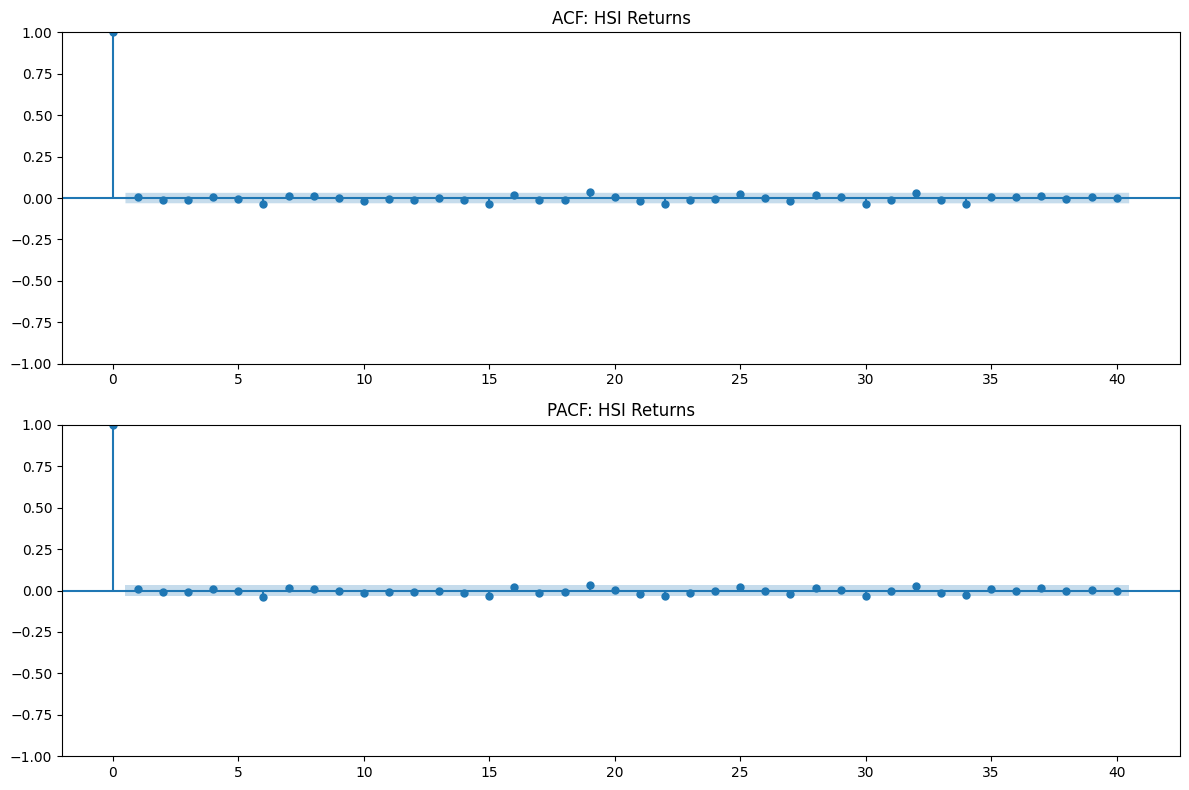

In [ ]:
#Q2: Are returns autocorrelated? Why it matters for this project:
#Our strategy is based on trend-following / momentum logic. Trend-following basically assumes that price movement has some persistence.

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# -----------------------------
# 1. Download HSI price data
# -----------------------------

ticker = "^HSI"

prices = yf.download(
    ticker,
    start="2010-01-01",
    auto_adjust=True
)["Close"]

# Sometimes yfinance returns a DataFrame instead of a Series.
# This makes sure we have one clean price series.
if isinstance(prices, pd.DataFrame):
    prices = prices.iloc[:, 0]

prices = prices.dropna()

# -----------------------------
# 2. Create dataset
# -----------------------------

df = pd.DataFrame()

# Price = closing level of the Hang Seng Index.
df["price"] = prices

# Daily return = percentage change from yesterday's price to today's price.
# Example:
# If price goes from 20000 to 20200, return = 1%.
df["daily_return"] = df["price"].pct_change()

# -----------------------------
# 3. Moving averages
# -----------------------------

# 50-day moving average:
# Average price over the last 50 trading days.
# This represents the medium-term trend.
df["ma_50"] = df["price"].rolling(50).mean()

# 200-day moving average:
# Average price over the last 200 trading days.
# This represents the long-term trend.
df["ma_200"] = df["price"].rolling(200).mean()

# -----------------------------
# 4. Rolling volatility
# -----------------------------

# 60-day rolling volatility:
# Standard deviation of daily returns over the last 60 trading days.
# Then we annualize it by multiplying by sqrt(252).
#
# 252 is used because there are about 252 trading days in one year.
df["rolling_vol_60"] = df["daily_return"].rolling(60).std() * np.sqrt(252)

# -----------------------------
# 5. Volatility regime
# -----------------------------

# Volatility threshold:
# We use the median rolling volatility as the cutoff.
# If rolling volatility is above this level, we call it High Vol.
# If rolling volatility is below this level, we call it Low Vol.
vol_threshold = df["rolling_vol_60"].median()

df["vol_regime"] = np.where(
    df["rolling_vol_60"] > vol_threshold,
    "High Vol",
    "Low Vol"
)

# -----------------------------
# 6. Clean dataset
# -----------------------------

# Drop missing rows.
# Missing rows happen because moving averages and rolling volatility
# need enough past data before they can be calculated.
df = df.dropna()

from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# HSI daily returns from our Day 21 dataset
hsi_returns = df["daily_return"].dropna()

lags_to_check = [1, 2, 3, 5, 10, 21]

print("HSI Autocorrelation Table")
print("-" * 40)

for lag in lags_to_check:
    autocorr = hsi_returns.autocorr(lag=lag)
    print(f"Lag {lag}: {autocorr:.4f}")

lb = acorr_ljungbox(
    hsi_returns,
    lags=[10],
    return_df=True
)

p_value = lb["lb_pvalue"].iloc[0]

print("\nLjung-Box Test")
print("-" * 40)
print(f"P-value at lag 10: {p_value:.4f}")

if p_value < 0.05:
    print("Interpretation: Evidence of autocorrelation up to lag 10.")
else:
    print("Interpretation: No strong evidence of autocorrelation up to lag 10.")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(hsi_returns, lags=40, ax=axes[0])
axes[0].set_title("ACF: HSI Returns")

plot_pacf(hsi_returns, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF: HSI Returns")

plt.tight_layout()
plt.show()

A2: HSI daily returns do not strongly depend on previous daily returns. There is no strong evidence of autocorrelation up to lag 10. This weakens simple short-term momentum strategies like:

If yesterday was positive, buy today.

In [ ]:
#Q3: Does trend-following work?

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# -----------------------------
# 1. Download HSI price data
# -----------------------------

ticker = "^HSI"

prices = yf.download(
    ticker,
    start="2010-01-01",
    auto_adjust=True
)["Close"]

# Sometimes yfinance returns a DataFrame instead of a Series.
# This makes sure we have one clean price series.
if isinstance(prices, pd.DataFrame):
    prices = prices.iloc[:, 0]

prices = prices.dropna()

# -----------------------------
# 2. Create dataset
# -----------------------------

df = pd.DataFrame()

# Price = closing level of the Hang Seng Index.
df["price"] = prices

# Daily return = percentage change from yesterday's price to today's price.
# Example:
# If price goes from 20000 to 20200, return = 1%.
df["daily_return"] = df["price"].pct_change()

# -----------------------------
# 3. Moving averages
# -----------------------------

# 50-day moving average:
# Average price over the last 50 trading days.
# This represents the medium-term trend.
df["ma_50"] = df["price"].rolling(50).mean()

# 200-day moving average:
# Average price over the last 200 trading days.
# This represents the long-term trend.
df["ma_200"] = df["price"].rolling(200).mean()

# -----------------------------
# 4. Rolling volatility
# -----------------------------

# 60-day rolling volatility:
# Standard deviation of daily returns over the last 60 trading days.
# Then we annualize it by multiplying by sqrt(252).
#
# 252 is used because there are about 252 trading days in one year.
df["rolling_vol_60"] = df["daily_return"].rolling(60).std() * np.sqrt(252)

# -----------------------------
# 5. Volatility regime
# -----------------------------

# Volatility threshold:
# We use the median rolling volatility as the cutoff.
# If rolling volatility is above this level, we call it High Vol.
# If rolling volatility is below this level, we call it Low Vol.
vol_threshold = df["rolling_vol_60"].median()

df["vol_regime"] = np.where(
    df["rolling_vol_60"] > vol_threshold,
    "High Vol",
    "Low Vol"
)

# -----------------------------
# 6. Clean dataset
# -----------------------------

# Drop missing rows.
# Missing rows happen because moving averages and rolling volatility
# need enough past data before they can be calculated.
df = df.dropna()

# ------------------------------------------------------------
# Trend-following check: 50-day MA vs 200-day MA
# ------------------------------------------------------------

# Signal:
# 1 means invested in HSI.
# 0 means stay in cash.
df["trend_signal"] = np.where(df["ma_50"] > df["ma_200"], 1, 0)

# Shift the signal by 1 day to avoid look-ahead bias.
# Meaning:
# today's position is based on information available yesterday.
df["trend_position"] = df["trend_signal"].shift(1)

# Strategy return:
# If position = 1, we earn HSI daily return.
# If position = 0, we earn 0.
df["trend_return"] = df["trend_position"] * df["daily_return"]

# Buy-and-hold return:
# Always invested in HSI.
df["buy_hold_return"] = df["daily_return"]

# Drop missing values created by shift.
strategy_df = df.dropna().copy()

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def total_return(r):
    # Total return over the full period.
    return (1 + r).prod() - 1

def annualized_return(r):
    # Converts total growth into average yearly growth.
    years = len(r) / 252
    return (1 + total_return(r)) ** (1 / years) - 1

def annualized_volatility(r):
    # Converts daily volatility into yearly volatility.
    return r.std() * np.sqrt(252)

def sharpe_ratio(r):
    # Return per unit of risk.
    # Risk-free rate assumed to be 0 for simplicity.
    vol = annualized_volatility(r)
    if vol == 0:
        return np.nan
    return annualized_return(r) / vol

def max_drawdown(r):
    # Drawdown means decline from previous peak.
    # Max drawdown is the worst peak-to-trough loss.
    equity_curve = (1 + r).cumprod()
    running_peak = equity_curve.cummax()
    drawdown = equity_curve / running_peak - 1
    return drawdown.min()

def number_of_trades(position):
    # Counts how many times position changes.
    # Example: 0 to 1 means enter trade, 1 to 0 means exit trade.
    return position.diff().abs().sum()

# ------------------------------------------------------------
# Performance comparison
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Buy and Hold": [
        total_return(strategy_df["buy_hold_return"]),
        annualized_return(strategy_df["buy_hold_return"]),
        annualized_volatility(strategy_df["buy_hold_return"]),
        sharpe_ratio(strategy_df["buy_hold_return"]),
        max_drawdown(strategy_df["buy_hold_return"]),
        1
    ],
    "Trend Strategy": [
        total_return(strategy_df["trend_return"]),
        annualized_return(strategy_df["trend_return"]),
        annualized_volatility(strategy_df["trend_return"]),
        sharpe_ratio(strategy_df["trend_return"]),
        max_drawdown(strategy_df["trend_return"]),
        number_of_trades(strategy_df["trend_position"])
    ]
}, index=[
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown",
    "Number of Trades"
])

# Format percentage rows nicely.
display_comparison = comparison.copy()

percent_rows = [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown"
]

for row in percent_rows:
    display_comparison.loc[row] = display_comparison.loc[row] * 100

print("TREND-FOLLOWING PERFORMANCE CHECK")
print("-" * 50)
print(display_comparison.round(2))

[*********************100%***********************]  1 of 1 completed

TREND-FOLLOWING PERFORMANCE CHECK
--------------------------------------------------
                       Buy and Hold  Trend Strategy
Total Return                   4.91          -25.52
Annualized Return              0.31           -1.90
Annualized Volatility         21.03           14.28
Sharpe Ratio                   0.01           -0.13
Max Drawdown                 -55.70          -55.74
Number of Trades               1.00           21.00


A3: The 50/200 moving-average trend strategy did/did not improve HSI performance relative to buy-and-hold.

The trend-following strategy failed here because:

- It produced lower returns.
- It had a worse Sharpe ratio.
- It did not meaningfully reduce max drawdown.
- It traded 21 times instead of simply holding once.

That means the 50/200 MA crossover probably got whipsawed.

In [ ]:
#Q4: Is performance different in high-vol vs low-vol regimes?

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# -----------------------------
# 1. Download HSI price data
# -----------------------------

ticker = "^HSI"

prices = yf.download(
    ticker,
    start="2010-01-01",
    auto_adjust=True
)["Close"]

# Sometimes yfinance returns a DataFrame instead of a Series.
# This makes sure we have one clean price series.
if isinstance(prices, pd.DataFrame):
    prices = prices.iloc[:, 0]

prices = prices.dropna()

# -----------------------------
# 2. Create dataset
# -----------------------------

df = pd.DataFrame()

# Price = closing level of the Hang Seng Index.
df["price"] = prices

# Daily return = percentage change from yesterday's price to today's price.
# Example:
# If price goes from 20000 to 20200, return = 1%.
df["daily_return"] = df["price"].pct_change()

# -----------------------------
# 3. Moving averages
# -----------------------------

# 50-day moving average:
# Average price over the last 50 trading days.
# This represents the medium-term trend.
df["ma_50"] = df["price"].rolling(50).mean()

# 200-day moving average:
# Average price over the last 200 trading days.
# This represents the long-term trend.
df["ma_200"] = df["price"].rolling(200).mean()

# -----------------------------
# 4. Rolling volatility
# -----------------------------

# 60-day rolling volatility:
# Standard deviation of daily returns over the last 60 trading days.
# Then we annualize it by multiplying by sqrt(252).
#
# 252 is used because there are about 252 trading days in one year.
df["rolling_vol_60"] = df["daily_return"].rolling(60).std() * np.sqrt(252)

# -----------------------------
# 5. Volatility regime
# -----------------------------

# Volatility threshold:
# We use the median rolling volatility as the cutoff.
# If rolling volatility is above this level, we call it High Vol.
# If rolling volatility is below this level, we call it Low Vol.
vol_threshold = df["rolling_vol_60"].median()

df["vol_regime"] = np.where(
    df["rolling_vol_60"] > vol_threshold,
    "High Vol",
    "Low Vol"
)

# -----------------------------
# 6. Clean dataset
# -----------------------------

# Drop missing rows.
# Missing rows happen because moving averages and rolling volatility
# need enough past data before they can be calculated.
df = df.dropna()

# ------------------------------------------------------------
# Trend-following check: 50-day MA vs 200-day MA
# ------------------------------------------------------------

# Signal:
# 1 means invested in HSI.
# 0 means stay in cash.
df["trend_signal"] = np.where(df["ma_50"] > df["ma_200"], 1, 0)

# Shift the signal by 1 day to avoid look-ahead bias.
# Meaning:
# today's position is based on information available yesterday.
df["trend_position"] = df["trend_signal"].shift(1)

# Strategy return:
# If position = 1, we earn HSI daily return.
# If position = 0, we earn 0.
df["trend_return"] = df["trend_position"] * df["daily_return"]

# Buy-and-hold return:
# Always invested in HSI.
df["buy_hold_return"] = df["daily_return"]

# Drop missing values created by shift.
strategy_df = df.dropna().copy()

# ------------------------------------------------------------
# Regime performance check
# ------------------------------------------------------------

# We are checking whether performance changes depending on market regime.
# High Vol = high volatility environment.
# Low Vol = calmer volatility environment.

regime_df = df.dropna().copy()

# ------------------------------------------------------------
# Helper function for performance stats
# ------------------------------------------------------------

def performance_stats_by_regime(data, return_column):
    """
    This function calculates performance separately for High Vol and Low Vol regimes.

    return_column:
    The return series we want to analyze.
    Example:
    - "daily_return" for buy-and-hold
    - "trend_return" for trend strategy
    """

    rows = []

    for regime in ["High Vol", "Low Vol"]:
        regime_data = data[data["vol_regime"] == regime]
        r = regime_data[return_column].dropna()

        total_ret = (1 + r).prod() - 1

        years = len(r) / 252

        ann_ret = (1 + total_ret) ** (1 / years) - 1

        ann_vol = r.std() * np.sqrt(252)

        # Sharpe ratio = return per unit of risk.
        # Higher Sharpe means better risk-adjusted performance.
        sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan

        # Max drawdown:
        # Worst peak-to-trough loss inside that regime sample.
        equity = (1 + r).cumprod()
        peak = equity.cummax()
        drawdown = equity / peak - 1
        max_dd = drawdown.min()

        rows.append({
            "Regime": regime,
            "Total Return": total_ret,
            "Annualized Return": ann_ret,
            "Annualized Volatility": ann_vol,
            "Sharpe Ratio": sharpe,
            "Max Drawdown": max_dd,
            "Observations": len(r)
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# Calculate regime stats
# ------------------------------------------------------------

buy_hold_by_regime = performance_stats_by_regime(
    regime_df,
    "daily_return"
)

trend_by_regime = performance_stats_by_regime(
    regime_df,
    "trend_return"
)

# Add labels so we know which strategy each table belongs to.
buy_hold_by_regime["Strategy"] = "Buy and Hold"
trend_by_regime["Strategy"] = "Trend Strategy"

regime_performance = pd.concat(
    [buy_hold_by_regime, trend_by_regime],
    ignore_index=True
)

# Make Strategy and Regime appear first.
regime_performance = regime_performance[
    [
        "Strategy",
        "Regime",
        "Total Return",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Max Drawdown",
        "Observations"
    ]
]

# ------------------------------------------------------------
# Display clean percentage format
# ------------------------------------------------------------

display_regime_performance = regime_performance.copy()

percent_columns = [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown"
]

for col in percent_columns:
    display_regime_performance[col] = display_regime_performance[col] * 100

display_regime_performance = display_regime_performance.round({
    "Total Return": 2,
    "Annualized Return": 2,
    "Annualized Volatility": 2,
    "Sharpe Ratio": 2,
    "Max Drawdown": 2,
    "Observations": 0
})

print("PERFORMANCE BY VOLATILITY REGIME")
print("-" * 60)
print(display_regime_performance.to_string(index=False))

[*********************100%***********************]  1 of 1 completed

PERFORMANCE BY VOLATILITY REGIME
------------------------------------------------------------
      Strategy   Regime  Total Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Max Drawdown  Observations
  Buy and Hold High Vol        -35.54              -5.61                  25.39         -0.22        -62.24          1917
  Buy and Hold  Low Vol         62.79               6.50                  15.58          0.42        -27.65          1949
Trend Strategy High Vol        -37.37              -5.97                  15.06         -0.40        -56.42          1917
Trend Strategy  Low Vol         18.92               2.27                  13.46          0.17        -29.83          1949


A4: Yes, performance is very different across regimes.

HSI performs much better in low-volatility regimes. Buy-and-hold returns were positive in low-vol periods, with lower volatility, better Sharpe ratio, and smaller drawdowns. In high-volatility regimes, HSI had negative returns, higher risk, negative Sharpe, and much deeper drawdowns.

The trend strategy also performs better in low-vol regimes than high-vol regimes, but it still does not beat buy-and-hold during low-vol periods. This means the regime filter is useful, but the 50/200 moving-average trend signal itself is not strong enough.

In [3]:
#Q5: Does volatility targeting improve risk?

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# -----------------------------
# 1. Download HSI price data
# -----------------------------

ticker = "^HSI"

prices = yf.download(
    ticker,
    start="2010-01-01",
    auto_adjust=True
)["Close"]

# Sometimes yfinance returns a DataFrame instead of a Series.
# This makes sure we have one clean price series.
if isinstance(prices, pd.DataFrame):
    prices = prices.iloc[:, 0]

prices = prices.dropna()

# -----------------------------
# 2. Create dataset
# -----------------------------

df = pd.DataFrame()

# Price = closing level of the Hang Seng Index.
df["price"] = prices

# Daily return = percentage change from yesterday's price to today's price.
# Example:
# If price goes from 20000 to 20200, return = 1%.
df["daily_return"] = df["price"].pct_change()

# -----------------------------
# 3. Moving averages
# -----------------------------

# 50-day moving average:
# Average price over the last 50 trading days.
# This represents the medium-term trend.
df["ma_50"] = df["price"].rolling(50).mean()

# 200-day moving average:
# Average price over the last 200 trading days.
# This represents the long-term trend.
df["ma_200"] = df["price"].rolling(200).mean()

# -----------------------------
# 4. Rolling volatility
# -----------------------------

# 60-day rolling volatility:
# Standard deviation of daily returns over the last 60 trading days.
# Then we annualize it by multiplying by sqrt(252).
#
# 252 is used because there are about 252 trading days in one year.
df["rolling_vol_60"] = df["daily_return"].rolling(60).std() * np.sqrt(252)

# -----------------------------
# 5. Volatility regime
# -----------------------------

# Volatility threshold:
# We use the median rolling volatility as the cutoff.
# If rolling volatility is above this level, we call it High Vol.
# If rolling volatility is below this level, we call it Low Vol.
vol_threshold = df["rolling_vol_60"].median()

df["vol_regime"] = np.where(
    df["rolling_vol_60"] > vol_threshold,
    "High Vol",
    "Low Vol"
)

# -----------------------------
# 6. Clean dataset
# -----------------------------

# Drop missing rows.
# Missing rows happen because moving averages and rolling volatility
# need enough past data before they can be calculated.
df = df.dropna()


# -----------------------------
# 7. Build basic moving-average strategy
# -----------------------------

df["ma_signal"] = np.where(df["ma_50"] > df["ma_200"], 1, 0)
df["ma_signal"] = df["ma_signal"].shift(1)
df["strategy_return"] = df["ma_signal"] * df["daily_return"]

# -----------------------------
# 8. Volatility targeting
# -----------------------------

target_vol = 0.10  # target 10% annual volatility

df["position_size"] = target_vol / df["rolling_vol_60"]

# Cap at 1.0 means the strategy can reduce exposure,
# but it cannot use leverage above 100%.
df["position_size"] = df["position_size"].clip(upper=1.0)

# Shift by 1 day so we use yesterday's known volatility.
df["position_size"] = df["position_size"].shift(1)

df["vol_targeted_strategy_return"] = (
    df["strategy_return"] * df["position_size"]
)

df = df.dropna()

original_vol = df["strategy_return"].std() * np.sqrt(252)
targeted_vol = df["vol_targeted_strategy_return"].std() * np.sqrt(252)

print("Original annualized volatility:", f"{original_vol:.2%}")
print("Vol-targeted annualized volatility:", f"{targeted_vol:.2%}")

def max_drawdown(return_series):
    wealth = (1 + return_series).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1
    return drawdown.min()

comparison = pd.DataFrame({
    "Original Strategy": {
        "Annualized Volatility": original_vol,
        "Max Drawdown": max_drawdown(df["strategy_return"]),
        "Worst Day": df["strategy_return"].min()
    },
    "Vol-Targeted Strategy": {
        "Annualized Volatility": targeted_vol,
        "Max Drawdown": max_drawdown(df["vol_targeted_strategy_return"]),
        "Worst Day": df["vol_targeted_strategy_return"].min()
    }
})

print((comparison * 100).round(2))

[*********************100%***********************]  1 of 1 completed

Original annualized volatility: 14.28%
Vol-targeted annualized volatility: 8.15%
                       Original Strategy  Vol-Targeted Strategy
Annualized Volatility              14.28                   8.15
Max Drawdown                      -55.74                 -34.27
Worst Day                         -13.22                  -5.16


A5: Yes. Volatility targeting improved risk.
It reduced annualized volatility, reduced max drawdown, and made the worst day much less severe.

In [5]:
# Q6: Is there any evidence the strategy is robust?
# Fixed version:
# Return/volatility/drawdown numbers are displayed as percentages.
# Sharpe ratio is displayed as a normal ratio, NOT multiplied by 100.

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Download HSI price data
# -----------------------------

ticker = "^HSI"

prices = yf.download(
    ticker,
    start="2010-01-01",
    auto_adjust=True
)["Close"]

if isinstance(prices, pd.DataFrame):
    prices = prices.iloc[:, 0]

prices = prices.dropna()

# -----------------------------
# 2. Helper functions
# -----------------------------

def max_drawdown(return_series):
    """
    Max drawdown measures the worst peak-to-trough loss.

    Example:
    If strategy wealth goes from 100 to 70 before recovering,
    the drawdown is -30%.
    """
    wealth = (1 + return_series).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1
    return drawdown.min()


def performance_stats(return_series):
    """
    Converts daily returns into key performance metrics.
    """
    return_series = return_series.dropna()

    total_return = (1 + return_series).prod() - 1
    annualized_return = (1 + return_series.mean()) ** 252 - 1
    annualized_volatility = return_series.std() * np.sqrt(252)

    if annualized_volatility == 0:
        sharpe_ratio = np.nan
    else:
        sharpe_ratio = annualized_return / annualized_volatility

    return pd.Series({
        "Total Return": total_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown(return_series),
        "Worst Day": return_series.min()
    })


def format_performance_table(table):
    """
    Formats performance metrics correctly.

    Percent metrics are multiplied by 100:
    - Total Return
    - Annualized Return
    - Annualized Volatility
    - Max Drawdown
    - Worst Day

    Sharpe Ratio is NOT multiplied by 100 because it is a ratio,
    not a percentage.
    """
    display = table.copy()

    percent_rows = [
        "Total Return",
        "Annualized Return",
        "Annualized Volatility",
        "Max Drawdown",
        "Worst Day"
    ]

    for row in percent_rows:
        if row in display.index:
            display.loc[row] = display.loc[row] * 100

    return display.round(2)


def build_strategy(prices, short_window, long_window):
    """
    Builds a moving-average trend-following strategy.

    Rule:
    If short moving average > long moving average, be invested.
    Otherwise, stay in cash.

    The signal is shifted by 1 day to avoid look-ahead bias.
    """
    df = pd.DataFrame()
    df["price"] = prices
    df["daily_return"] = df["price"].pct_change()

    df["short_ma"] = df["price"].rolling(short_window).mean()
    df["long_ma"] = df["price"].rolling(long_window).mean()

    df["signal"] = np.where(df["short_ma"] > df["long_ma"], 1, 0)

    # Shift signal so today's return uses yesterday's known signal.
    df["signal"] = df["signal"].shift(1)

    df["strategy_return"] = df["signal"] * df["daily_return"]

    # Buy-and-hold means always invested in HSI.
    df["buy_hold_return"] = df["daily_return"]

    # Rolling volatility for regime classification.
    df["rolling_vol_60"] = df["daily_return"].rolling(60).std() * np.sqrt(252)

    vol_threshold = df["rolling_vol_60"].median()

    df["vol_regime"] = np.where(
        df["rolling_vol_60"] > vol_threshold,
        "High Vol",
        "Low Vol"
    )

    df = df.dropna()

    return df


# -----------------------------
# 3. Main strategy: 50 / 200 MA
# -----------------------------

main_df = build_strategy(
    prices=prices,
    short_window=50,
    long_window=200
)

print("MAIN STRATEGY: 50/200 MOVING AVERAGE")
print("-" * 50)

main_comparison = pd.DataFrame({
    "Buy and Hold": performance_stats(main_df["buy_hold_return"]),
    "50/200 MA Strategy": performance_stats(main_df["strategy_return"])
})

print(format_performance_table(main_comparison))

# -----------------------------
# 4. In-sample vs out-of-sample test
# -----------------------------

split_point = int(len(main_df) * 0.70)

train = main_df.iloc[:split_point]
test = main_df.iloc[split_point:]

train_test_comparison = pd.DataFrame({
    "Train Strategy": performance_stats(train["strategy_return"]),
    "Test Strategy": performance_stats(test["strategy_return"]),
    "Train BuyHold": performance_stats(train["buy_hold_return"]),
    "Test BuyHold": performance_stats(test["buy_hold_return"])
})

print("\nIN-SAMPLE VS OUT-OF-SAMPLE")
print("-" * 50)
print(format_performance_table(train_test_comparison))

# -----------------------------
# 5. Parameter sensitivity test
# -----------------------------

parameter_sets = [
    (40, 150),
    (50, 150),
    (50, 200),
    (60, 200),
    (75, 250),
    (100, 300)
]

parameter_results = []

for short_window, long_window in parameter_sets:
    test_df = build_strategy(
        prices=prices,
        short_window=short_window,
        long_window=long_window
    )

    stats = performance_stats(test_df["strategy_return"])

    parameter_results.append({
        "Short MA": short_window,
        "Long MA": long_window,
        "Total Return": stats["Total Return"],
        "Annualized Return": stats["Annualized Return"],
        "Annualized Volatility": stats["Annualized Volatility"],
        "Sharpe Ratio": stats["Sharpe Ratio"],
        "Max Drawdown": stats["Max Drawdown"],
        "Worst Day": stats["Worst Day"]
    })

parameter_results = pd.DataFrame(parameter_results)

parameter_display = parameter_results.copy()

percent_columns = [
    "Total Return",
    "Annualized Return",
    "Annualized Volatility",
    "Max Drawdown",
    "Worst Day"
]

for col in percent_columns:
    parameter_display[col] = parameter_display[col] * 100

print("\nPARAMETER SENSITIVITY TEST")
print("-" * 50)
print(parameter_display.round(2))

# -----------------------------
# 6. Regime robustness test
# -----------------------------

regime_results = {}

for regime_name in ["High Vol", "Low Vol"]:
    regime_data = main_df[main_df["vol_regime"] == regime_name]

    regime_results[regime_name] = performance_stats(
        regime_data["strategy_return"]
    )

regime_results = pd.DataFrame(regime_results)

print("\nSTRATEGY PERFORMANCE BY VOLATILITY REGIME")
print("-" * 50)
print(format_performance_table(regime_results))

# -----------------------------
# 7. Final prompts for interpretation
# -----------------------------

print("\nROBUSTNESS CHECK PROMPTS")
print("-" * 50)

print("1. Does the strategy survive out-of-sample, or does it collapse?")
print("2. Do nearby MA settings behave similarly, or does only one setting work?")
print("3. Is performance concentrated in only one volatility regime?")
print("4. Does the strategy offer better risk-adjusted performance than buy-and-hold?")
print("5. If the answer is mixed, call it partially robust, not fully robust.")

[*********************100%***********************]  1 of 1 completed


MAIN STRATEGY: 50/200 MOVING AVERAGE
--------------------------------------------------
                       Buy and Hold  50/200 MA Strategy
Total Return                   5.76              -25.52
Annualized Return              2.61               -0.89
Annualized Volatility         21.02               14.27
Sharpe Ratio                   0.12               -0.06
Max Drawdown                 -55.70              -55.74
Worst Day                    -13.22              -13.22

IN-SAMPLE VS OUT-OF-SAMPLE
--------------------------------------------------
                       Train Strategy  Test Strategy  Train BuyHold  \
Total Return                   -33.27          11.60          10.01   
Annualized Return               -2.89           3.94           2.70   
Annualized Volatility           12.86          17.12          18.82   
Sharpe Ratio                    -0.22           0.23           0.14   
Max Drawdown                   -41.60         -27.65         -35.59   
Worst Day      

1. It performs better out-of-sample than in-sample.
2. Several alternative MA settings have positive total returns.
3. Low-volatility regime performance is much better.
4. Volatility targeting reduced risk in Q5.

The evidence suggests conditional robustness rather than full robustness. Strategy performance is sensitive to parameter choice and volatility regime, so further out-of-sample testing and regime-aware risk controls are required before treating it as reliable.